[                       0%                       ]

Acessando API do Yahoo Finance...


[*********************100%***********************]  4 of 4 completed


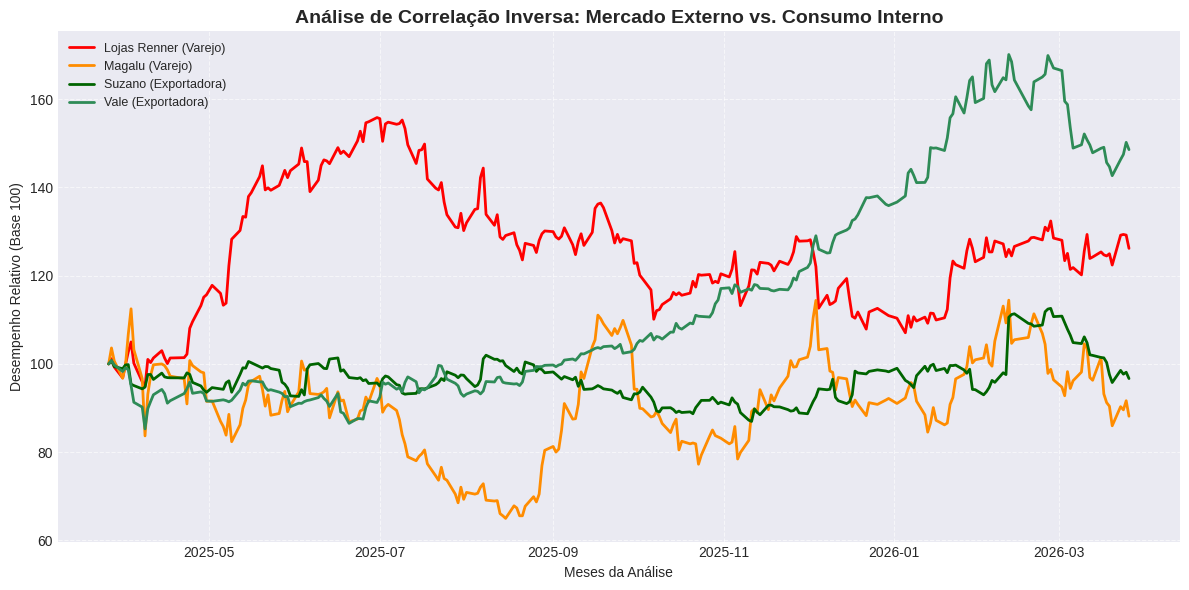


--- MATRIZ DE CORRELAÇÃO (Retornos Diários) ---
                       Lojas Renner (Varejo)  Magalu (Varejo)  \
Lojas Renner (Varejo)                   1.00             0.57   
Magalu (Varejo)                         0.57             1.00   
Suzano (Exportadora)                    0.11             0.14   
Vale (Exportadora)                      0.24             0.29   

                       Suzano (Exportadora)  Vale (Exportadora)  
Lojas Renner (Varejo)                  0.11                0.24  
Magalu (Varejo)                        0.14                0.29  
Suzano (Exportadora)                   1.00                0.30  
Vale (Exportadora)                     0.30                1.00  


In [9]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. DEFINIÇÃO DOS ATIVOS (Ações reais da B3)
# Exportadoras: Ganham com a alta do dólar e mercado externo
# Varejo: Sofrem com a alta dos juros e inflação interna
tickers = {
    'SUZB3.SA': 'Suzano (Exportadora)',
    'VALE3.SA': 'Vale (Exportadora)',
    'MGLU3.SA': 'Magalu (Varejo)',
    'LREN3.SA': 'Lojas Renner (Varejo)'
}

# 2. CAPTURA DE DADOS EM TEMPO REAL (Último 1 ano até hoje)
print("Acessando API do Yahoo Finance...")
data_fim = datetime.now()
data_inicio = data_fim - timedelta(days=365)

# O yfinance baixa os dados mais recentes disponíveis no servidor
dados = yf.download(list(tickers.keys()), start=data_inicio, end=data_fim)['Close']

# Renomeando as colunas para facilitar a leitura no gráfico
dados.columns = [tickers[t] for t in dados.columns]
dados = dados.dropna()

# 3. NORMALIZAÇÃO (Base 100)
# Como a Vale custa ~R$ 60 e a Magalu ~R$ 2, precisamos que todas comecem em 100
# para ver quem subiu ou desceu proporcionalmente.
dados_norm = (dados / dados.iloc[0]) * 100

# 4. CONSTRUÇÃO DO GRÁFICO DE CORRELAÇÃO
plt.figure(figsize=(12, 6))

# Cores para diferenciar os grupos
cores = {
    'Suzano (Exportadora)': '#006400', # Verde Escuro
    'Vale (Exportadora)': '#2E8B57',   # Verde Marinho
    'Magalu (Varejo)': '#FF8C00',      # Laranja
    'Lojas Renner (Varejo)': '#FF0000' # Vermelho
}

for coluna in dados_norm.columns:
    plt.plot(dados_norm.index, dados_norm[coluna], label=coluna, color=cores[coluna], lw=2)

# Formatação visual
plt.title('Análise de Correlação Inversa: Mercado Externo vs. Consumo Interno', fontsize=14, fontweight='bold')
plt.xlabel('Meses da Análise')
plt.ylabel('Desempenho Relativo (Base 100)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. CÁLCULO MATEMÁTICO DA CORRELAÇÃO
print("\n--- MATRIZ DE CORRELAÇÃO (Retornos Diários) ---")
retornos = dados.pct_change().dropna()
print(retornos.corr().round(2))